In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [6]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

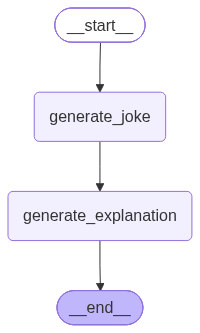

In [9]:
workflow

In [7]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.',
   'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster applying th

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster a

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster 

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': [{'type': 'text',
   'text': "Why do pasta chefs live such dangerous lives?\n\nBecause they're always living on the *penne* edge!",
   'extras': {'signature': 'El0KWwERTTIP69BLdcB2cpyqLUlNSt/mkTsphJd3wgzPv9KCCu+QyPywXPTKX0DJkf0xA/KAPXGNDm3yZXkI2iSOjkG+dAuCS7jMx7Tr0dpKucgQ0bzmuCIobzVVs5g='}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that relies on two main elements:\n\n1. **The idiom:** The phrase "living on the *edge*" (or "living on the cutting edge") refers to living a dangerous, risky, or thrilling lifestyle.\n2. **The pasta:** **Penne** is a type of tube-shaped pasta with angled edges. \n\nThe joke connects the two by replacing the word "razor\'s" (as in "living on a razor\'s edge") with **"penne,"** creating a humorous pun that sounds like "penny edge."',
   'extras': {'signature': 'El0KWwERTTIPfZiHXFDrBh5qjqpJde4EjhiuIv61CPyrxNGiYeYsW+Wbxbj8MhpeuXLCMN3J+FTRqdNip3+go3DQPUUg5x3GPFeWqIJn6S8cv4k3Z682lwXEGqQ1XrI='}

In [12]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster a

In [13]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster 

In [15]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1ad82c-889c-6b76-8002-b9ce91cf09a6"}})

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster a

In [17]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1ad82c-889c-6b76-8002-b9ce91cf09a6"}})

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.',
   'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster applying th

In [18]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster 

In [20]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_ns": "", "checkpoint_id": "1f1ad82c-889c-6b76-8002-b9ce91cf09a6"}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1ad853-56aa-6530-8003-606d6dfd0c61'}}

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster

In [22]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1ad82c-889c-6b76-8002-b9ce91cf09a6"}})

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.',
   'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster applying th

In [23]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn the roof of his mouth on his pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El0KWwERTTIPK6aWYg+35/8PB9Q0i/NhbwzBdO8SijraerLgD8ZRVaF50kxvU3Hc4f0l2zL2bb79NYZjG6dKubfia5ZFwhTHhrfV43MDDAL4GkoOsMUAj3NlE5NtLHk='}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on two different meanings of the word **"cool":**\n\n1. **Temperature:** When food comes out of the oven, it is hot. People usually wait for it to cool down before eating it to avoid burning themselves.\n2. **Trendy/Popular:** In slang, "hipster" is a subculture associated with being overly concerned with being trendy, liking obscure things, and saying things like, *"I liked that band before they were cool."*\n\n**The joke:**\nA hipster famously wants to like things *before* anyone else does (before they become mainstream or "cool"). The joke imagines the hipster 

In [24]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [25]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [26]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [27]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [1]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))